In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers accelerate wandb scikit-learn seaborn

import os
import re
import random
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import wandb

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

Mounted at /content/drive


# **Exploratory Data Analysis**

In [2]:
base_path = "/content/drive/MyDrive/DI725_assignment1_dataset"
train_path = f"{base_path}/train.csv"
test_path = f"{base_path}/test.csv"

# Load
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

Sentiment Distribution


Train Set Sentiment Distribution class distribution:
customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64


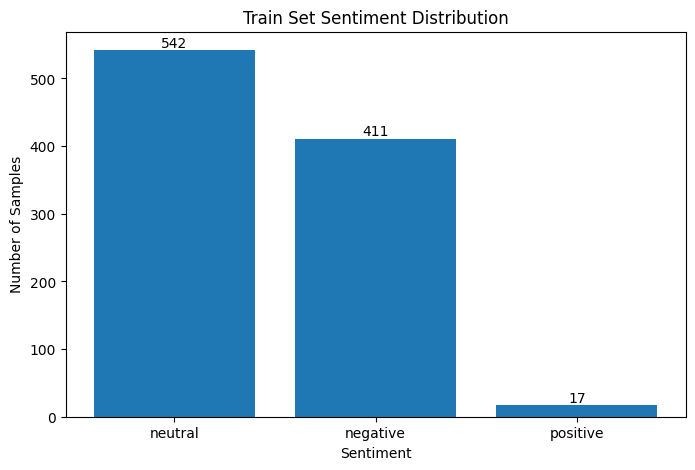


Test Set Sentiment Distribution class distribution:
customer_sentiment
negative    10
neutral     10
positive    10
Name: count, dtype: int64


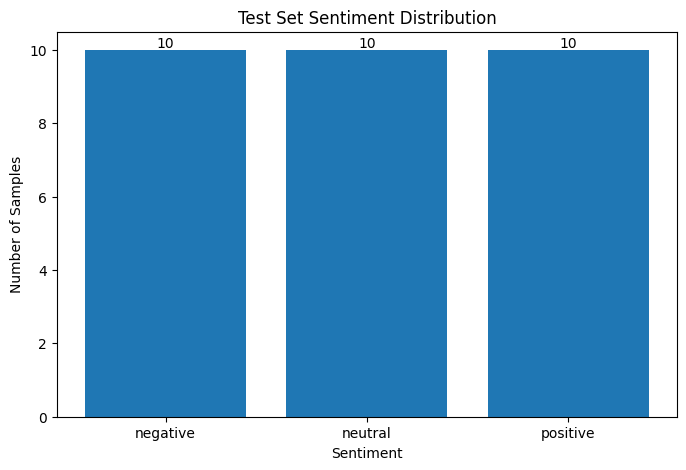

In [ ]:
###Matplotlib codes were generated with the aid of ChatGPT

# Function to visualize class distribution of sentiment labels
def plot_sentiment_distribution(df, title, label_col="customer_sentiment"):
    
    # Count number of samples per class
    class_counts = df[label_col].value_counts()

    # Print distribution values
    print(f"\n{title} class distribution:")
    print(class_counts)

    # Create bar plot
    plt.figure(figsize=(8,5))
    bars = plt.bar(class_counts.index.astype(str), class_counts.values)

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )

    # Set plot titles and labels
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Samples")

    # Display the plot
    plt.show()


# Visualize sentiment distribution for train and test sets
plot_sentiment_distribution(train_df, "Train Set Sentiment Distribution")
plot_sentiment_distribution(test_df, "Test Set Sentiment Distribution")

Conversation Leghts( To see if we need to normalize)

Train conversation length summary:
count     970.000000
mean     2129.284536
std       564.751035
min        46.000000
25%      1760.250000
50%      2058.500000
75%      2430.000000
max      5708.000000
Name: conversation_length, dtype: float64

Test conversation length summary:
count      30.000000
mean     2178.566667
std       828.185873
min      1125.000000
25%      1772.500000
50%      2092.500000
75%      2459.250000
max      5496.000000
Name: conversation_length, dtype: float64


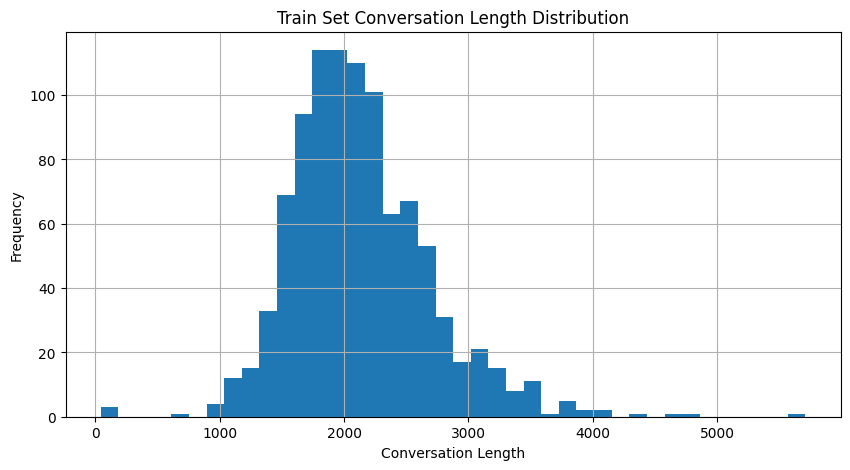

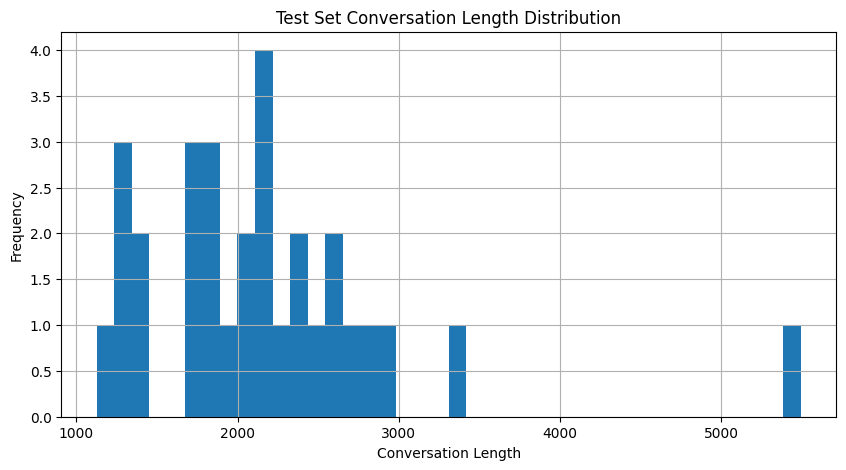

In [4]:
train_df["conversation_length"] = train_df["conversation"].astype(str).apply(len)
test_df["conversation_length"] = test_df["conversation"].astype(str).apply(len)

print("Train conversation length summary:")
print(train_df["conversation_length"].describe())

print("\nTest conversation length summary:")
print(test_df["conversation_length"].describe())


plt.figure(figsize=(10,5))
train_df["conversation_length"].hist(bins=40)
plt.title("Train Set Conversation Length Distribution")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
test_df["conversation_length"].hist(bins=40)
plt.title("Test Set Conversation Length Distribution")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.show()

Average conversation length by sentiment:
customer_sentiment
negative    2395.454988
neutral     1940.826568
positive    1702.705882
Name: conversation_length, dtype: float64


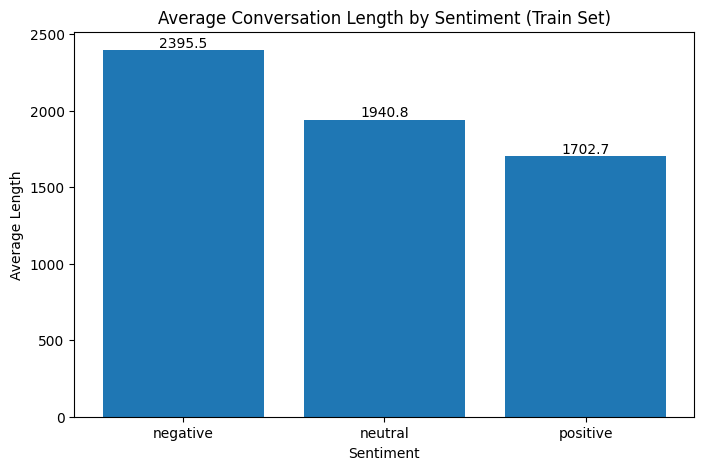

In [5]:
avg_len_by_sentiment = train_df.groupby("customer_sentiment")["conversation_length"].mean().sort_values(ascending=False)

print("Average conversation length by sentiment:")
print(avg_len_by_sentiment)

plt.figure(figsize=(8,5))
bars = plt.bar(avg_len_by_sentiment.index, avg_len_by_sentiment.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Conversation Length by Sentiment (Train Set)")
plt.xlabel("Sentiment")
plt.ylabel("Average Length")
plt.show()

Correlations

customer_sentiment         negative   neutral  positive
issue_area                                             
Cancellations and returns  0.490975  0.509025  0.000000
Login and Account          0.187919  0.812081  0.000000
Order                      0.604651  0.329457  0.065891
Shipping                   0.528571  0.471429  0.000000
Shopping                   0.318584  0.681416  0.000000
Warranty                   0.174757  0.825243  0.000000


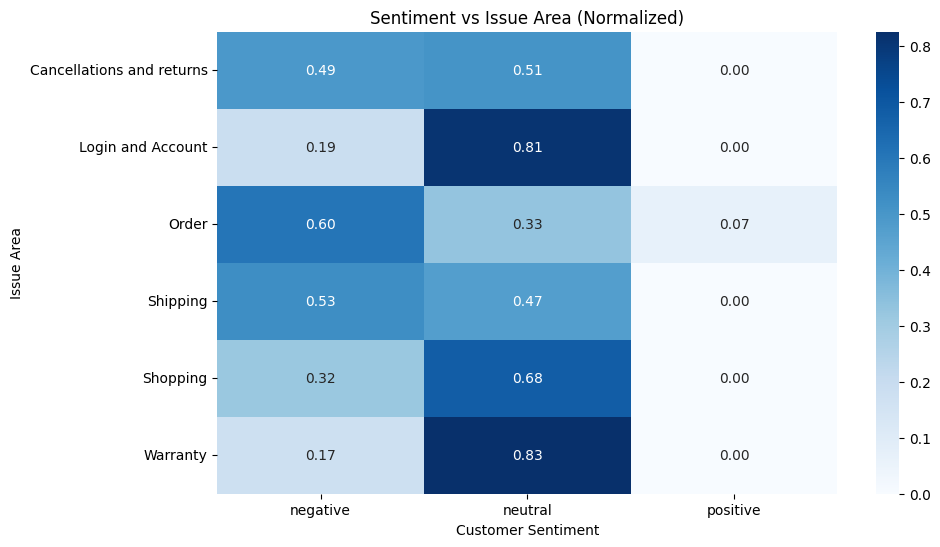

customer_sentiment  negative   neutral  positive
product_category                                
Appliances          0.418502  0.561674  0.019824
Electronics         0.416382  0.580205  0.003413
Men/Women/Kids      0.443946  0.524664  0.031390


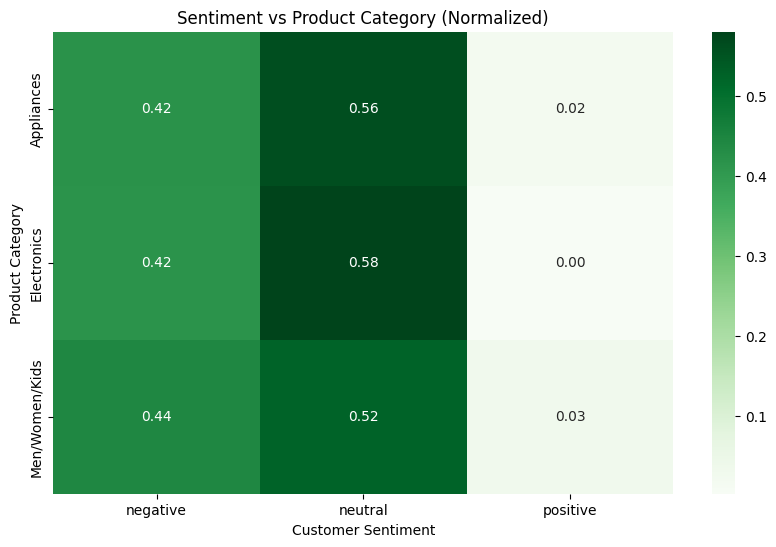

customer_sentiment  negative   neutral  positive
issue_complexity                                
high                0.475610  0.487805  0.036585
less                0.417373  0.567797  0.014831
medium              0.420673  0.562500  0.016827


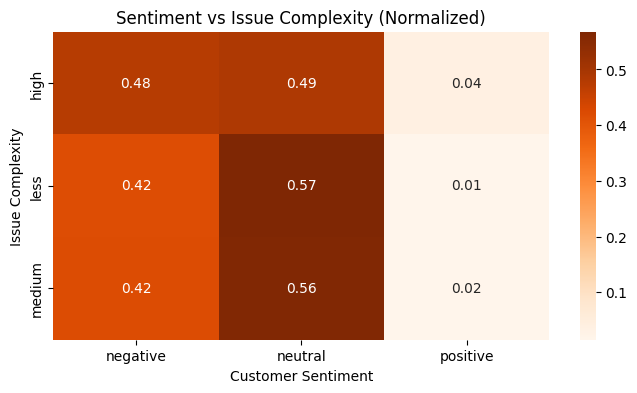

customer_sentiment      negative   neutral  positive
agent_experience_level                              
experienced             0.433628  0.554572  0.011799
inexperienced           0.333333  0.659574  0.007092
junior                  0.442857  0.532653  0.024490


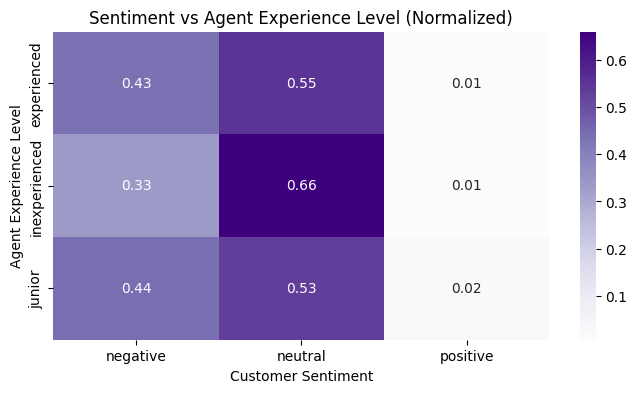

In [ ]:

ct_issue_area = pd.crosstab(
    train_df["issue_area"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_issue_area)

plt.figure(figsize=(10,6))
sns.heatmap(ct_issue_area, annot=True, cmap="Blues", fmt=".2f")
plt.title("Sentiment vs Issue Area (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Issue Area")
plt.show()

ct_product = pd.crosstab(
    train_df["product_category"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_product)

plt.figure(figsize=(10,6))
sns.heatmap(ct_product, annot=True, cmap="Greens", fmt=".2f")
plt.title("Sentiment vs Product Category (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Product Category")
plt.show()

ct_complexity = pd.crosstab(
    train_df["issue_complexity"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_complexity)

plt.figure(figsize=(8,4))
sns.heatmap(ct_complexity, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Sentiment vs Issue Complexity (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Issue Complexity")
plt.show()

ct_agent = pd.crosstab(
    train_df["agent_experience_level"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_agent)

plt.figure(figsize=(8,4))
sns.heatmap(ct_agent, annot=True, cmap="Purples", fmt=".2f")
plt.title("Sentiment vs Agent Experience Level (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Agent Experience Level")
plt.show()

# **Data Preprocessing**

In [ ]:


# Create numeric labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
train_df["label"] = train_df["customer_sentiment"].map(label_map)

# Split only train.csv into train and validation
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["customer_sentiment"]
)

print("Train split shape:", train_split_df.shape)
print("Validation split shape:", val_split_df.shape)

print("\nTrain split sentiment distribution:")
print(train_split_df["customer_sentiment"].value_counts())

print("\nValidation split sentiment distribution:")
print(val_split_df["customer_sentiment"].value_counts())

base_path = "/content/drive/MyDrive/DI725_assignment1_dataset"

train_split_path = f"{base_path}/train_split.csv"
val_split_path = f"{base_path}/val_split.csv"

train_split_df.to_csv(train_split_path, index=False)
val_split_df.to_csv(val_split_path, index=False)

print("Saved:")
print(train_split_path)
print(val_split_path)

Train split shape: (873, 13)
Validation split shape: (97, 13)

Train split sentiment distribution:
customer_sentiment
neutral     488
negative    370
positive     15
Name: count, dtype: int64

Validation split sentiment distribution:
customer_sentiment
neutral     54
negative    41
positive     2
Name: count, dtype: int64
Saved:
/content/drive/MyDrive/DI725_assignment1_dataset/train_split.csv
/content/drive/MyDrive/DI725_assignment1_dataset/val_split.csv


preprop

Processed train shape: (872, 3)
Processed val shape: (97, 3)
Processed test shape: (30, 3)

Train Set Sentiment Distribution class distribution:
customer_sentiment
neutral     488
negative    369
positive     15
Name: count, dtype: int64


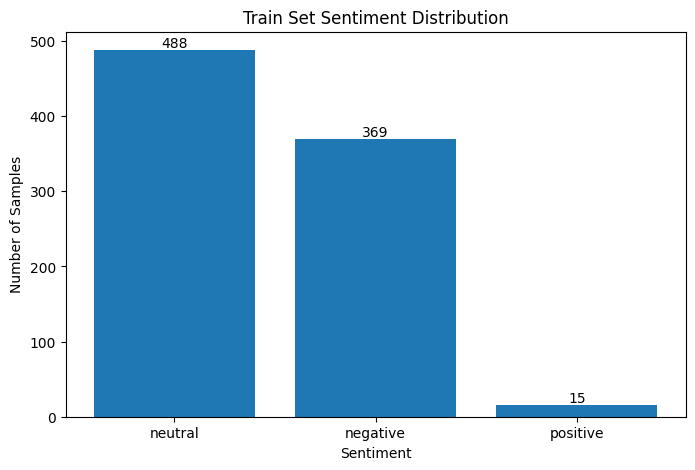


Val Set Sentiment Distribution class distribution:
customer_sentiment
neutral     54
negative    41
positive     2
Name: count, dtype: int64


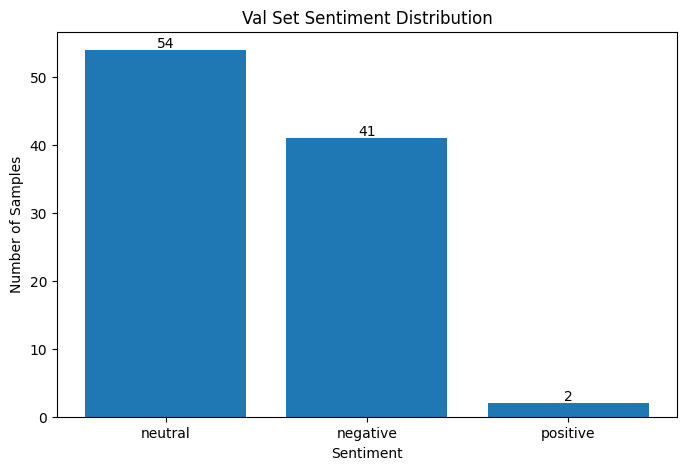


Test Set Sentiment Distribution class distribution:
customer_sentiment
negative    10
neutral     10
positive    10
Name: count, dtype: int64


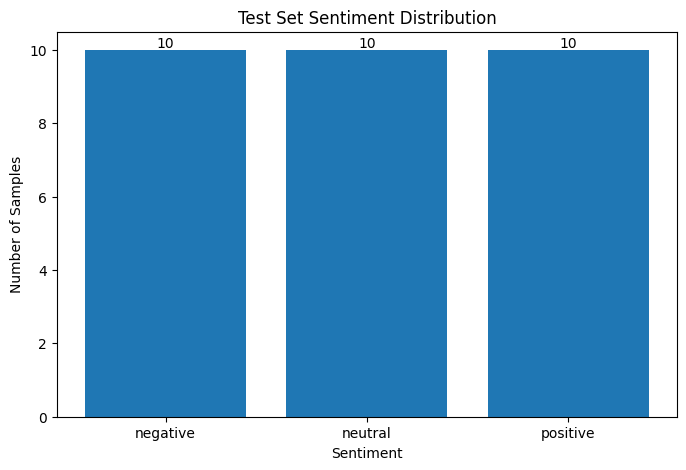

In [ ]:


# Reload clean copies if needed
train_split_df = pd.read_csv(f"{base_path}/train_split.csv")
val_split_df = pd.read_csv(f"{base_path}/val_split.csv")
test_df = pd.read_csv(f"{base_path}/test.csv")

def clean_conversation(text):
    # Convert to string
    text = str(text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_dataframe(df, text_col="conversation", label_col="customer_sentiment"):
    df = df.copy()

    # Keep only necessary columns
    df = df[[text_col, label_col]].copy()

    # Drop missing rows
    df = df.dropna(subset=[text_col, label_col])

    # Drop duplicate rows
    df = df.drop_duplicates()

    # Clean text
    df[text_col] = df[text_col].apply(clean_conversation)

    # Encode labels
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    df["label"] = df[label_col].map(label_map)

    return df

train_processed = preprocess_dataframe(train_split_df)
val_processed = preprocess_dataframe(val_split_df)
test_processed = preprocess_dataframe(test_df)

print("Processed train shape:", train_processed.shape)
print("Processed val shape:", val_processed.shape)
print("Processed test shape:", test_processed.shape)

plot_sentiment_distribution(train_processed, "Train Set Sentiment Distribution")
plot_sentiment_distribution(val_processed, "Val Set Sentiment Distribution")
plot_sentiment_distribution(test_processed, "Test Set Sentiment Distribution")

In [9]:
train_processed.to_csv(f"{base_path}/train_processed.csv", index=False)
val_processed.to_csv(f"{base_path}/val_processed.csv", index=False)
test_processed.to_csv(f"{base_path}/test_processed.csv", index=False)

print("Processed CSV files saved.")

Processed CSV files saved.


# **MODEL**

In [ ]:
#Seed is set for code reproducibility(like wanted in the assignment)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [ ]:
BASE_PATH = "/content/drive/MyDrive/DI725_assignment1_dataset"
PROJECT_NAME = "DI725-assignment1-bestconfig-experiment"
NUM_LABELS = 3
CLASS_NAMES = ["negative", "neutral", "positive"]

#Load data ready for training
train_df = pd.read_csv(f"{BASE_PATH}/train_processed.csv")
val_df   = pd.read_csv(f"{BASE_PATH}/val_processed.csv")
test_df  = pd.read_csv(f"{BASE_PATH}/test_processed.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())


Train shape: (872, 3)
Val shape: (97, 3)
Test shape: (30, 3)


,conversation,customer_sentiment,label
0,"Customer: Hi, I need to return a sweatshirt th...",negative,0
1,Agent: Thank you for calling BrownBox Customer...,negative,0
2,"Agent: Hello, thank you for contacting BrownBo...",neutral,1
3,"Customer: Hello, I want to return a washing ma...",neutral,1
4,"Customer: Hi, I'm trying to purchase an invert...",neutral,1


In [ ]:
#To overcome imbalanced class problem  class weights are calculated
y_train = train_df["label"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

#Dataset class
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_length, text_col="conversation", label_col="label"):
        self.texts = df[text_col].astype(str).reset_index(drop=True)
        self.labels = df[label_col].astype(int).reset_index(drop=True)
        self.encodings = tokenizer(
            self.texts.tolist(),
            truncation=True,
            padding=False,
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

#Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

Class weights: tensor([ 0.7877,  0.5956, 19.3778])


In [ ]:
#Trainer class
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )
        logits = outputs["logits"]

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
#Helper functions -args and get_predictions_without_wandb were written with the aid of GPT
def build_tokenizer(config):
    return AutoTokenizer.from_pretrained(config["model_name"])

def build_model(config):
    return AutoModelForSequenceClassification.from_pretrained(
        config["model_name"],
        num_labels=NUM_LABELS
    )

def build_training_args(config):
    return TrainingArguments(
        output_dir=f"./results/{config['run_name']}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        num_train_epochs=config["epochs"],
        weight_decay=config["weight_decay"],
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="wandb",
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        seed=config["seed"]
    )

def get_predictions_without_wandb(trainer, dataset):
    model = trainer.model
    device = model.device
    model.eval()

    preds = []
    labels = []

    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=trainer.args.per_device_eval_batch_size,
        collate_fn=trainer.data_collator
    )

    with torch.no_grad():
        for batch in dataloader:
            labels.extend(batch["labels"].cpu().numpy())

            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1)

            preds.extend(batch_preds.cpu().numpy())

    return np.array(preds), np.array(labels)

def plot_confusion_matrix(preds, labels, class_names, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

    return cm


def run_experiment(config, train_df, val_df, test_df, class_weights):
    set_seed(config["seed"])

    wandb.init(
        project=PROJECT_NAME,
        name=config["run_name"],
        config=config,
        reinit=True
    )

    tokenizer = build_tokenizer(config)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    train_dataset = SentimentDataset(train_df, tokenizer, max_length=config["max_length"])
    val_dataset   = SentimentDataset(val_df, tokenizer, max_length=config["max_length"])
    test_dataset  = SentimentDataset(test_df, tokenizer, max_length=config["max_length"])

    model = build_model(config)
    training_args = build_training_args(config)

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    val_results = trainer.evaluate(eval_dataset=val_dataset)
    test_results = trainer.evaluate(eval_dataset=test_dataset)

    wandb.log({
        "final_val_accuracy": val_results["eval_accuracy"],
        "final_val_macro_f1": val_results["eval_macro_f1"],
        "final_test_accuracy": test_results["eval_accuracy"],
        "final_test_macro_f1": test_results["eval_macro_f1"]
    })

    wandb.finish()

    return {
        "run_name": config["run_name"],
        "model_name": config["model_name"],
        "config": config,
        "trainer": trainer,
        "tokenizer": tokenizer,
        "val_results": val_results,
        "test_results": test_results
    }

In [ ]:
#grid search for Wandb and experiemnts
def short_model_name(model_name):
    if model_name == "distilbert-base-uncased":
        return "distilbert"
    elif model_name == "distilroberta-base":
        return "distilroberta"
    return model_name

model_names = [
    "distilbert-base-uncased",
    "distilroberta-base"
]
learning_rates = [2e-5, 3e-5]
max_lengths = [128, 256]
batch_sizes = [8]
epochs_list = [5, 50]

configs = []
for model, lr, max_len, bs, ep in product(
    model_names, learning_rates, max_lengths, batch_sizes, epochs_list
):
    configs.append({
        "run_name": f"{short_model_name(model)}_lr{lr}_len{max_len}_bs{bs}_ep{ep}",
        "model_name": model,
        "learning_rate": lr,
        "max_length": max_len,
        "batch_size": bs,
        "epochs": ep,
        "weight_decay": 0.01,
        "seed": 42
    })

print(f"Total configs: {len(configs)}")

wandb.login()


Total configs: 16


True

In [ ]:
#Running the Experiments
all_results = []
summary_rows = []

for i, config in enumerate(configs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(configs)}] Running: {config['run_name']}")
    print(f"Model: {config['model_name']}")
    print(
        f"LR: {config['learning_rate']} | "
        f"Max Length: {config['max_length']} | "
        f"Batch Size: {config['batch_size']} | "
        f"Epochs: {config['epochs']}"
    )
    print(f"{'='*70}")

    result = run_experiment(config, train_df, val_df, test_df, class_weights)
    all_results.append(result)

    summary_rows.append({
        "run_name": result["run_name"],
        "model_name": result["model_name"],
        "learning_rate": config["learning_rate"],
        "max_length": config["max_length"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "val_accuracy": result["val_results"]["eval_accuracy"],
        "val_macro_f1": result["val_results"]["eval_macro_f1"],
        "test_accuracy": result["test_results"]["eval_accuracy"],
        "test_macro_f1": result["test_results"]["eval_macro_f1"]
    })



[1/16] Running: distilbert_lr2e-05_len128_bs8_ep5
Model: distilbert-base-uncased
LR: 2e-05 | Max Length: 128 | Batch Size: 8 | Epochs: 5


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.986880,0.879828,0.690722,0.465278,0.467965,0.480126
2,0.767926,0.730494,0.752577,0.506957,0.504120,0.519121
3,0.644496,0.689543,0.865979,0.581366,0.584244,0.583107
4,0.547879,0.683541,0.886598,0.596244,0.595153,0.599368
5,0.512304,0.698834,0.876289,0.589286,0.586502,0.593195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

eval/accuracy,▁▆▆▇▅█▇▇█▂
eval/loss,▁▁▁▃▃▄▄▄▄█
eval/macro_f1,▁▆▅▆▅▇▆▇▇█
eval/macro_precision,▁▃▃▃▃▄▃▃▄█
eval/macro_recall,▁▄▄▅▃▆▅▅▆█
eval/runtime,█▇█▇███▇█▁
eval/samples_per_second,▅█▅▇▆▅▆█▆▁
eval/steps_per_second,▅█▅▇▆▅▆█▆▁
final_test_accuracy,▁
final_test_macro_f1,▁
+7,...


In [ ]:
#Summary Table
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="val_macro_f1", ascending=False).reset_index(drop=True)

print("\nFINAL SUMMARY TABLE")
display(summary_df)

summary_path = f"{BASE_PATH}/grid_search_results.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary to:", summary_path)

#Selecting the best model based on macro F1
best_row = summary_df.iloc[0]
best_run_name = best_row["run_name"]

best_result = next(r for r in all_results if r["run_name"] == best_run_name)

print("\nBEST MODEL BASED ON VALIDATION MACRO F1")
display(pd.DataFrame([best_row]))



FINAL SUMMARY TABLE


,run_name,model_name,learning_rate,max_length,batch_size,epochs,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,distilroberta_lr2e-05_len256_bs8_ep50,distilroberta-base,0.00002,256,8,50,0.917526,0.617634,0.766667,0.753179
1,distilbert_lr2e-05_len128_bs8_ep5,distilbert-base-uncased,0.00002,128,8,5,0.886598,0.596244,0.533333,0.446759
2,distilroberta_lr3e-05_len256_bs8_ep50,distilroberta-base,0.00003,256,8,50,0.886598,0.596120,0.666667,0.619048
3,distilbert_lr3e-05_len128_bs8_ep5,distilbert-base-uncased,0.00003,128,8,5,0.886598,0.595328,0.533333,0.446759
4,distilroberta_lr3e-05_len128_bs8_ep5,distilroberta-base,0.00003,128,8,5,0.886598,0.595328,0.533333,0.446078
5,distilbert_lr3e-05_len128_bs8_ep50,distilbert-base-uncased,0.00003,128,8,50,0.876289,0.589286,0.700000,0.687912
6,distilbert_lr2e-05_len128_bs8_ep50,distilbert-base-uncased,0.00002,128,8,50,0.876289,0.588844,0.600000,0.500000
7,distilroberta_lr2e-05_len128_bs8_ep50,distilroberta-base,0.00002,128,8,50,0.876289,0.587723,0.566667,0.476530
8,distilroberta_lr2e-05_len128_bs8_ep5,distilroberta-base,0.00002,128,8,5,0.865979,0.581366,0.600000,0.504630
9,distilroberta_lr3e-05_len128_bs8_ep50,distilroberta-base,0.00003,128,8,50,0.855670,0.573805,0.566667,0.476530


Saved summary to: /content/drive/MyDrive/DI725_assignment1_dataset/grid_search_results.csv

BEST MODEL BASED ON VALIDATION MACRO F1


,run_name,model_name,learning_rate,max_length,batch_size,epochs,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,distilroberta_lr2e-05_len256_bs8_ep50,distilroberta-base,0.00002,256,8,50,0.917526,0.617634,0.766667,0.753179



CLASSIFICATION REPORT FOR BEST MODEL (TEST SET)
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        10
     neutral       0.59      1.00      0.74        10
    positive       1.00      0.40      0.57        10

    accuracy                           0.77        30
   macro avg       0.86      0.77      0.75        30
weighted avg       0.86      0.77      0.75        30



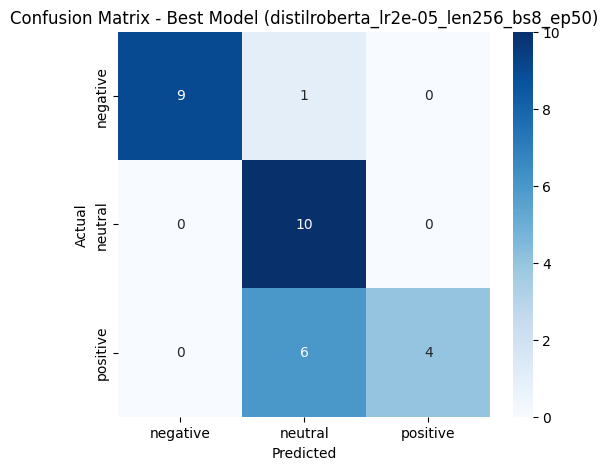


REPORT-READY TABLE


,run_name,Model,LR,Max Len,Batch Size,epochs,Val Macro F1,Test Macro F1
0,distilroberta_lr2e-05_len256_bs8_ep50,DistilRoBERTa,0.00002,256,8,50,0.618,0.753
1,distilbert_lr2e-05_len128_bs8_ep5,DistilBERT,0.00002,128,8,5,0.596,0.447
2,distilroberta_lr3e-05_len256_bs8_ep50,DistilRoBERTa,0.00003,256,8,50,0.596,0.619
3,distilbert_lr3e-05_len128_bs8_ep5,DistilBERT,0.00003,128,8,5,0.595,0.447
4,distilroberta_lr3e-05_len128_bs8_ep5,DistilRoBERTa,0.00003,128,8,5,0.595,0.446
5,distilbert_lr3e-05_len128_bs8_ep50,DistilBERT,0.00003,128,8,50,0.589,0.688
6,distilbert_lr2e-05_len128_bs8_ep50,DistilBERT,0.00002,128,8,50,0.589,0.500
7,distilroberta_lr2e-05_len128_bs8_ep50,DistilRoBERTa,0.00002,128,8,50,0.588,0.477
8,distilroberta_lr2e-05_len128_bs8_ep5,DistilRoBERTa,0.00002,128,8,5,0.581,0.505
9,distilroberta_lr3e-05_len128_bs8_ep50,DistilRoBERTa,0.00003,128,8,50,0.574,0.477


In [ ]:

#Best model predictions - classification report - heatmap (generated by GPT)

best_config = best_result["config"]
best_tokenizer = best_result["tokenizer"]
best_trainer = best_result["trainer"]

best_test_dataset = SentimentDataset(
    test_df,
    best_tokenizer,
    max_length=best_config["max_length"]
)

best_test_preds, best_test_labels = get_predictions_without_wandb(
    best_trainer,
    best_test_dataset
)

print("\nCLASSIFICATION REPORT FOR BEST MODEL (TEST SET)")
print(classification_report(
    best_test_labels,
    best_test_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))

cm = plot_confusion_matrix(
    best_test_preds,
    best_test_labels,
    CLASS_NAMES,
    title=f"Confusion Matrix - Best Model ({best_run_name})"
)

report_table = summary_df.copy()

report_table["model_name"] = report_table["model_name"].replace({
    "distilbert-base-uncased": "DistilBERT",
    "distilroberta-base": "DistilRoBERTa"
})

report_table = report_table.rename(columns={
    "model_name": "Model",
    "learning_rate": "LR",
    "max_length": "Max Len",
    "batch_size": "Batch Size",
    "val_macro_f1": "Val Macro F1",
    "test_macro_f1": "Test Macro F1"
})

report_table = report_table[[
    "run_name", "Model", "LR", "Max Len", "Batch Size", "epochs", "Val Macro F1", "Test Macro F1"
]]

report_table["Val Macro F1"] = report_table["Val Macro F1"].round(3)
report_table["Test Macro F1"] = report_table["Test Macro F1"].round(3)

print("\nREPORT-READY TABLE")
display(report_table)

CORRUPT METADATA SOLUTION (GENERATED BY CHATGPT)

In [ ]:
#I encountered problems when uploding to Github which are visible by my commits
#I shared the problem with ChatGPT and it generated this code and it solved my missing metadata problem
from google.colab import drive
drive.mount('/content/drive')
import json


input_path = "/content/drive/MyDrive/Colab Notebooks/DI725_assignment1_fullcode.ipynb"
output_path = "/content/drive/MyDrive/DI725_assignment1_fullcode_clean.ipynb"

with open(input_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove problematic widget metadata
if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Clean notebook saved to:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Clean notebook saved to: /content/drive/MyDrive/DI725_assignment1_fullcode_clean.ipynb
